# 02 — Visualisation & Key Questions
**Project:** Mental Health in Tech Survey (OSMI)  
**Goal:** Answer the 4 key research questions using charts.

**Questions:**
1. What percentage of tech employees seek mental health treatment?
2. Does family history influence treatment-seeking?
3. Do workplace benefits and company support affect mental health openness?
4. Are remote workers more or less likely to report mental health interference?

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Colour palette
C_BLUE   = '#3266ad'
C_GREEN  = '#1D9E75'
C_CORAL  = '#D85A30'
C_PURPLE = '#7F77DD'
C_GRAY   = '#888780'

print('Setup done.')

Setup done.


In [2]:
# Load cleaned data from 01_eda.ipynb
# If you skipped 01_eda, load the raw file and it will still work
try:
    df = pd.read_csv('survey_clean.csv')
    print('Loaded cleaned dataset.')
except FileNotFoundError:
    df = pd.read_csv('../data/survey.csv')
    # Quick clean
    df = df[(df['Age'] >= 18) & (df['Age'] <= 75)]
    def clean_gender(g):
        g = str(g).strip().lower()
        if g in ['male','m','man','cis male','cis man','male (cis)','malr','mail','msle','make']:
            return 'Male'
        elif g in ['female','f','woman','cis female','cis woman','female (cis)','femake','femail']:
            return 'Female'
        else:
            return 'Other'
    df['Gender'] = df['Gender'].apply(clean_gender)
    df['work_interfere'] = df['work_interfere'].fillna("Don't know")
    df['self_employed'] = df['self_employed'].fillna('No')
    print('Loaded raw dataset + applied quick clean.')

print(f'Shape: {df.shape}')
df.head(2)

Loaded cleaned dataset.
Shape: (1251, 28)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,Country_grouped
0,2014-08-27 11:29:31,37,Female,United States,IL,No,No,Yes,Often,6-25,...,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN,United States
1,2014-08-27 11:29:37,44,Male,United States,IN,No,No,No,Rarely,More than 1000,...,Maybe,No,No,No,No,No,Don't know,No,NaN,United States


---
## Q1 — What percentage of tech employees seek mental health treatment?

In [3]:
treatment_counts = df['treatment'].value_counts()
total = len(df)
pct_yes = treatment_counts.get('Yes', 0) / total * 100
pct_no  = treatment_counts.get('No', 0)  / total * 100

print(f'Sought treatment:     {pct_yes:.1f}%')
print(f'Did not seek:         {pct_no:.1f}%')

Sought treatment:     50.5%
Did not seek:         49.5%


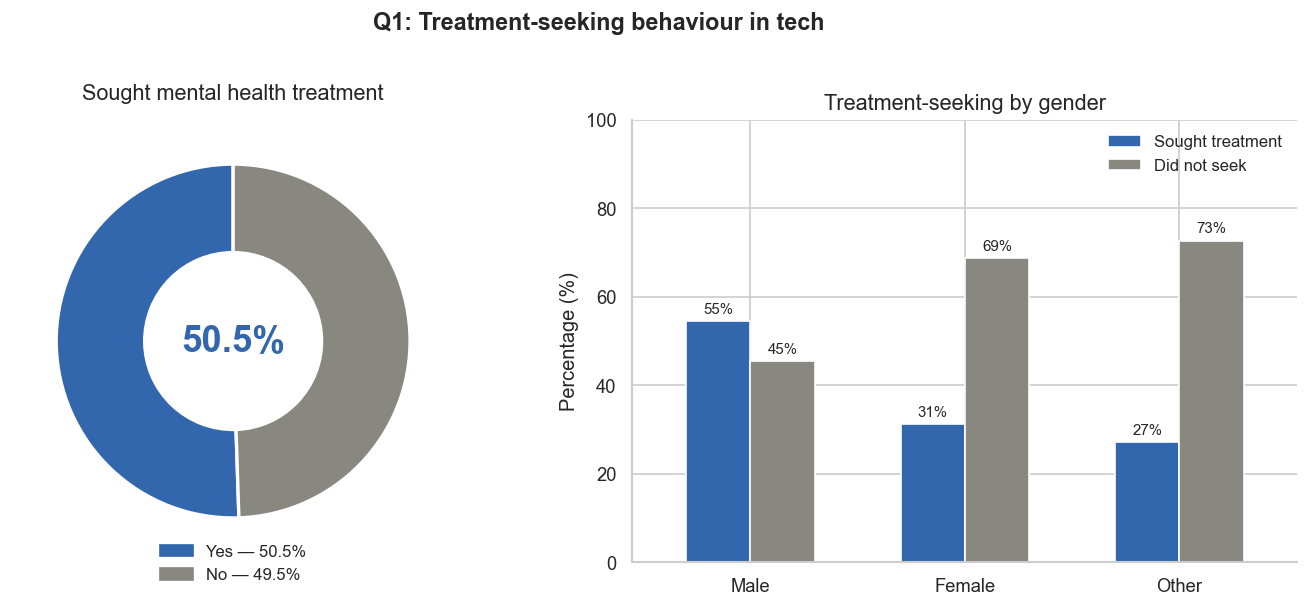

Saved: q1_treatment.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: donut chart ---
ax = axes[0]
sizes = [pct_yes, pct_no]
colors = [C_BLUE, C_GRAY]
wedges, texts = ax.pie(
    sizes, colors=colors, startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
ax.text(0, 0, f'{pct_yes:.1f}%', ha='center', va='center',
        fontsize=22, fontweight='bold', color=C_BLUE)
ax.set_title('Sought mental health treatment', fontsize=13, pad=12)
legend_patches = [
    mpatches.Patch(color=C_BLUE, label=f'Yes — {pct_yes:.1f}%'),
    mpatches.Patch(color=C_GRAY, label=f'No — {pct_no:.1f}%')
]
ax.legend(handles=legend_patches, loc='lower center', fontsize=10,
          bbox_to_anchor=(0.5, -0.08), frameon=False)

# --- Right: treatment by gender ---
ax2 = axes[1]
gender_treat = df.groupby('Gender')['treatment'].value_counts(normalize=True).unstack() * 100
gender_treat = gender_treat.reindex(['Male', 'Female', 'Other'])
gender_treat.plot(kind='bar', ax=ax2, color=[C_BLUE, C_GRAY], edgecolor='white', width=0.6)
ax2.set_title('Treatment-seeking by gender', fontsize=13)
ax2.set_ylabel('Percentage (%)')
ax2.set_xlabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(['Sought treatment', 'Did not seek'], frameon=False, fontsize=10)
ax2.set_ylim(0, 100)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0f}%',
                 (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Q1: Treatment-seeking behaviour in tech', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q1_treatment.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: q1_treatment.png')

**Insight:** About half of tech employees sought mental health treatment. Female respondents show notably higher treatment-seeking rates than male respondents.

---
## Q2 — Does family history influence treatment-seeking?

In [5]:
family_treat = df.groupby('family_history')['treatment'].value_counts(normalize=True).unstack() * 100
print('Treatment rate by family history:')
print(family_treat.round(1))

Treatment rate by family history:
treatment         No   Yes
family_history            
No              64.6  35.4
Yes             26.0  74.0


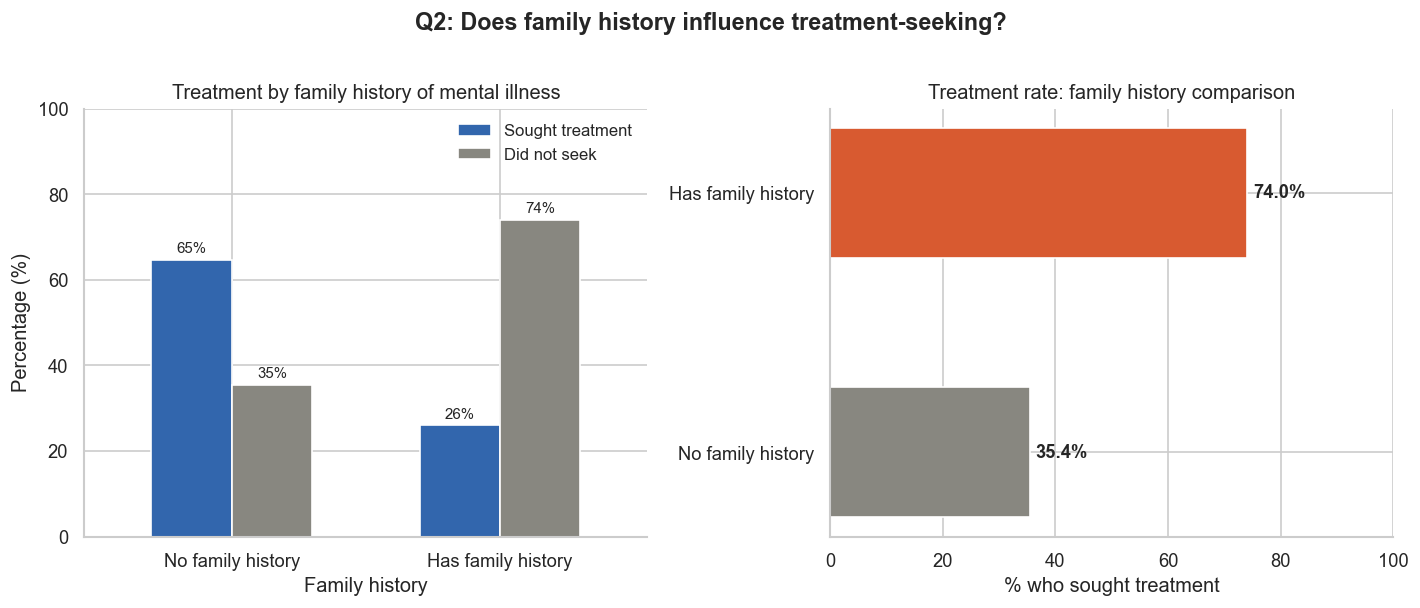

Saved: q2_family_history.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: grouped bar ---
ax = axes[0]
family_treat.plot(kind='bar', ax=ax, color=[C_BLUE, C_GRAY], edgecolor='white', width=0.6)
ax.set_title('Treatment by family history of mental illness', fontsize=12)
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Family history')
ax.set_xticklabels(['No family history', 'Has family history'], rotation=0)
ax.legend(['Sought treatment', 'Did not seek'], frameon=False, fontsize=10)
ax.set_ylim(0, 100)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%',
                (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha='center', va='bottom', fontsize=9)

# --- Right: stacked 100% bar ---
ax2 = axes[1]
# Treatment rate just for 'Yes' (sought treatment)
rate_no_fam  = family_treat.loc['No', 'Yes']  if 'Yes' in family_treat.columns else 0
rate_yes_fam = family_treat.loc['Yes', 'Yes'] if 'Yes' in family_treat.columns else 0

categories = ['No family history', 'Has family history']
rates = [rate_no_fam, rate_yes_fam]
bars = ax2.barh(categories, rates, color=[C_GRAY, C_CORAL], edgecolor='white', height=0.5)
ax2.set_xlim(0, 100)
ax2.set_xlabel('% who sought treatment')
ax2.set_title('Treatment rate: family history comparison', fontsize=12)
for bar, rate in zip(bars, rates):
    ax2.text(rate + 1, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.suptitle('Q2: Does family history influence treatment-seeking?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q2_family_history.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: q2_family_history.png')

**Insight:** Employees with a family history of mental illness are significantly more likely to seek treatment — suggesting awareness and normalisation within the family plays a key role.

---
## Q3 — Do workplace benefits and support affect mental health openness?

In [8]:
# Treatment rate by benefits, care_options, seek_help, wellness_program
support_cols = ['benefits', 'care_options', 'seek_help', 'wellness_program', 'anonymity']

for col in support_cols:
    if col in df.columns:
        rate = df.groupby(col)['treatment'].apply(lambda x: (x=='Yes').mean() * 100).round(1)
        print(f'\n--- {col} ---')
        print(rate)


--- benefits ---
benefits
Don't know    37.1
No            48.2
Yes           63.8
Name: treatment, dtype: float64

--- care_options ---
care_options
No          41.3
Not sure    39.3
Yes         69.0
Name: treatment, dtype: float64

--- seek_help ---
seek_help
Don't know    45.7
No            49.9
Yes           59.1
Name: treatment, dtype: float64

--- wellness_program ---
wellness_program
Don't know    43.3
No            49.8
Yes           59.0
Name: treatment, dtype: float64

--- anonymity ---
anonymity
Don't know    45.3
No            57.8
Yes           60.8
Name: treatment, dtype: float64


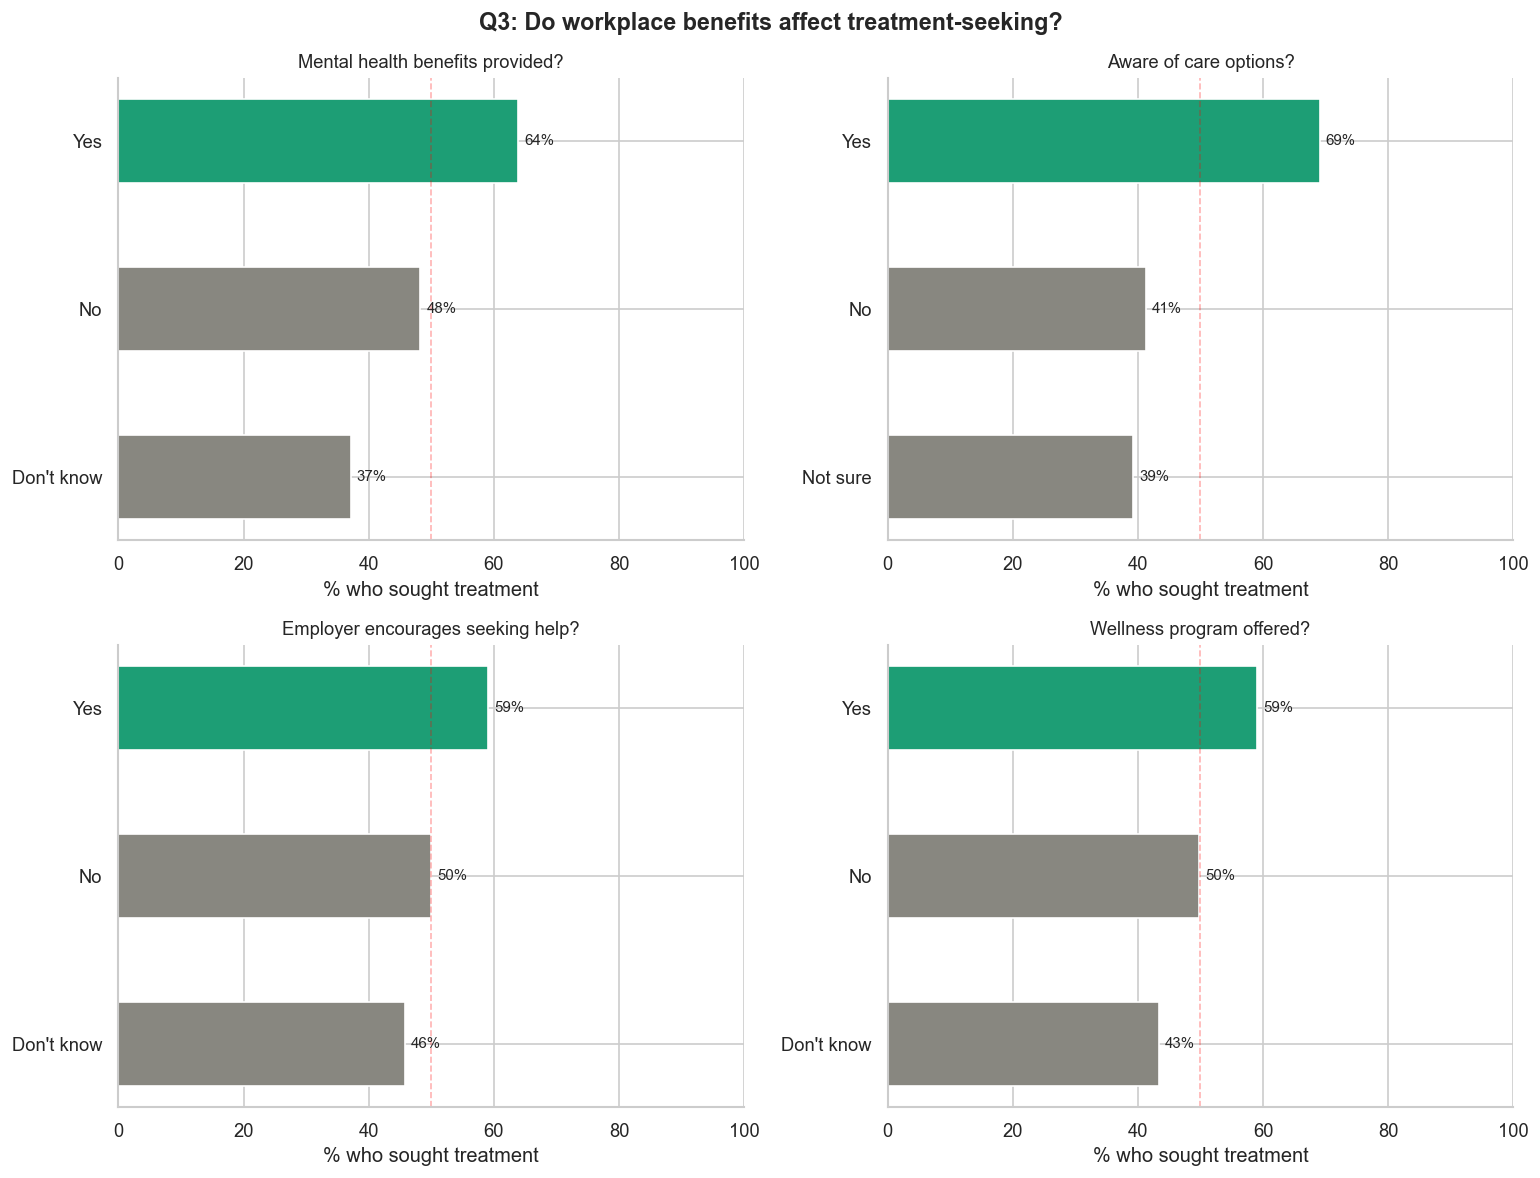

Saved: q3_benefits.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

support_plots = [
    ('benefits',          'Mental health benefits provided?'),
    ('care_options',      'Aware of care options?'),
    ('seek_help',         'Employer encourages seeking help?'),
    ('wellness_program',  'Wellness program offered?'),
]

for i, (col, title) in enumerate(support_plots):
    ax = axes[i]
    if col not in df.columns:
        ax.set_visible(False)
        continue
    rate = df.groupby(col)['treatment'].apply(lambda x: (x=='Yes').mean() * 100).reset_index()
    rate.columns = [col, 'treatment_rate']
    rate = rate.sort_values('treatment_rate', ascending=True)
    colors_bar = [C_GRAY if v < 50 else C_GREEN for v in rate['treatment_rate']]
    bars = ax.barh(rate[col].astype(str), rate['treatment_rate'],
                   color=colors_bar, edgecolor='white', height=0.5)
    ax.set_xlim(0, 100)
    ax.set_xlabel('% who sought treatment')
    ax.set_title(title, fontsize=11)
    ax.axvline(50, color='red', linestyle='--', alpha=0.3, linewidth=1)
    for bar, val in zip(bars, rate['treatment_rate']):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', fontsize=9)

plt.suptitle('Q3: Do workplace benefits affect treatment-seeking?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q3_benefits.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: q3_benefits.png')

**Insight:** Employees at companies that provide mental health benefits, care options, and wellness programs show consistently higher treatment-seeking rates. Workplace culture and support structures directly influence behaviour.

---
## Q4 — Are remote workers more or less likely to report mental health interference?

In [11]:
print('Work interference levels:')
print(df['work_interfere'].value_counts())
print('\nRemote work breakdown:')
print(df['remote_work'].value_counts())

Work interference levels:
Sometimes     464
Don't know    262
Never         212
Rarely        173
Often         140
Name: work_interfere, dtype: int64

Remote work breakdown:
No     880
Yes    371
Name: remote_work, dtype: int64


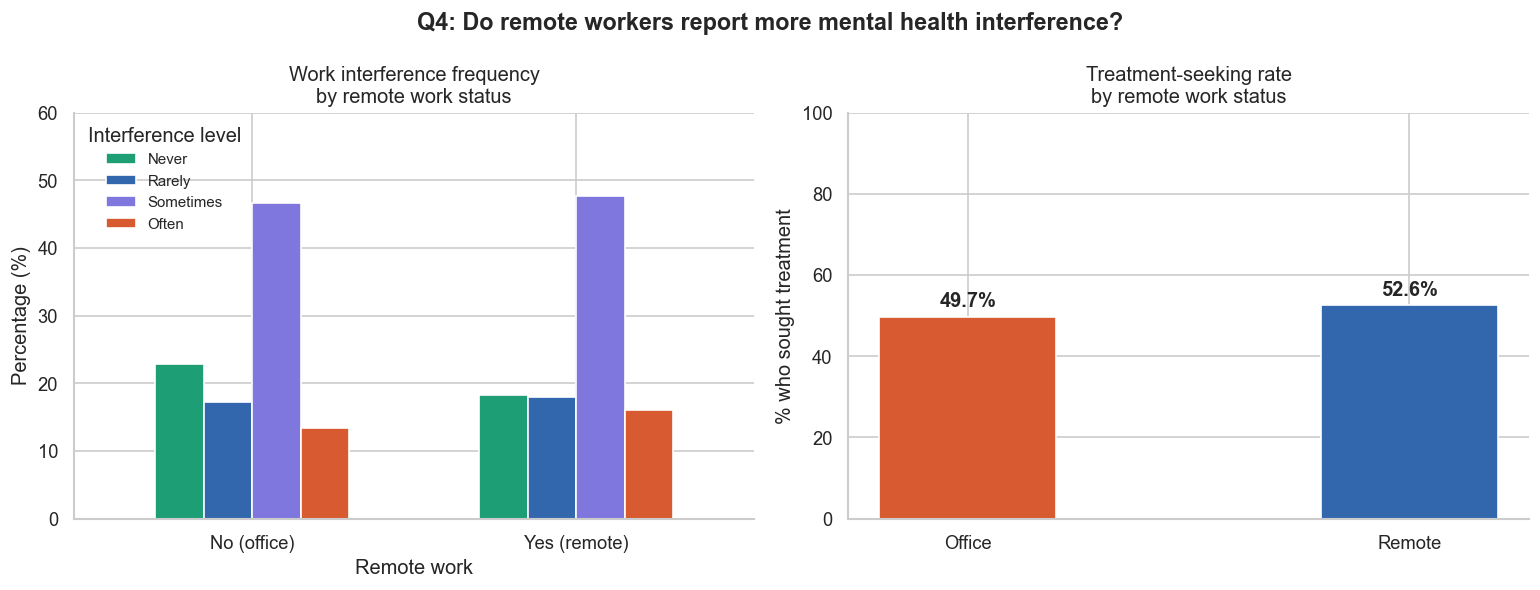

Saved: q4_remote.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: work_interfere by remote_work ---
ax = axes[0]
order = ['Never', 'Rarely', 'Sometimes', 'Often']
remote_interfere = df[df['work_interfere'].isin(order)].groupby(
    ['remote_work', 'work_interfere']
).size().unstack(fill_value=0)
remote_interfere = remote_interfere.div(remote_interfere.sum(axis=1), axis=0) * 100
remote_interfere = remote_interfere.reindex(columns=order)

remote_interfere.plot(
    kind='bar', ax=ax,
    color=[C_GREEN, C_BLUE, C_PURPLE, C_CORAL],
    edgecolor='white', width=0.6
)
ax.set_title('Work interference frequency\nby remote work status', fontsize=12)
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Remote work')
ax.set_xticklabels(['No (office)', 'Yes (remote)'], rotation=0)
ax.legend(title='Interference level', frameon=False, fontsize=9)
ax.set_ylim(0, 60)

# --- Right: treatment rate by remote work ---
ax2 = axes[1]
remote_treat = df.groupby('remote_work')['treatment'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
remote_treat.columns = ['remote_work', 'treatment_rate']
colors_bar = [C_CORAL if r == 'No' else C_BLUE for r in remote_treat['remote_work']]
bars = ax2.bar(
    remote_treat['remote_work'].map({'No': 'Office', 'Yes': 'Remote'}),
    remote_treat['treatment_rate'],
    color=colors_bar, edgecolor='white', width=0.4
)
ax2.set_ylim(0, 100)
ax2.set_title('Treatment-seeking rate\nby remote work status', fontsize=12)
ax2.set_ylabel('% who sought treatment')
ax2.set_xlabel('')
for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1.5,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.suptitle('Q4: Do remote workers report more mental health interference?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q4_remote.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: q4_remote.png')

**Insight:** Remote workers show slightly different patterns of work interference. Compare treatment-seeking rates between office and remote employees to draw conclusions for your report.

---
## Bonus — Summary dashboard (all 4 questions)

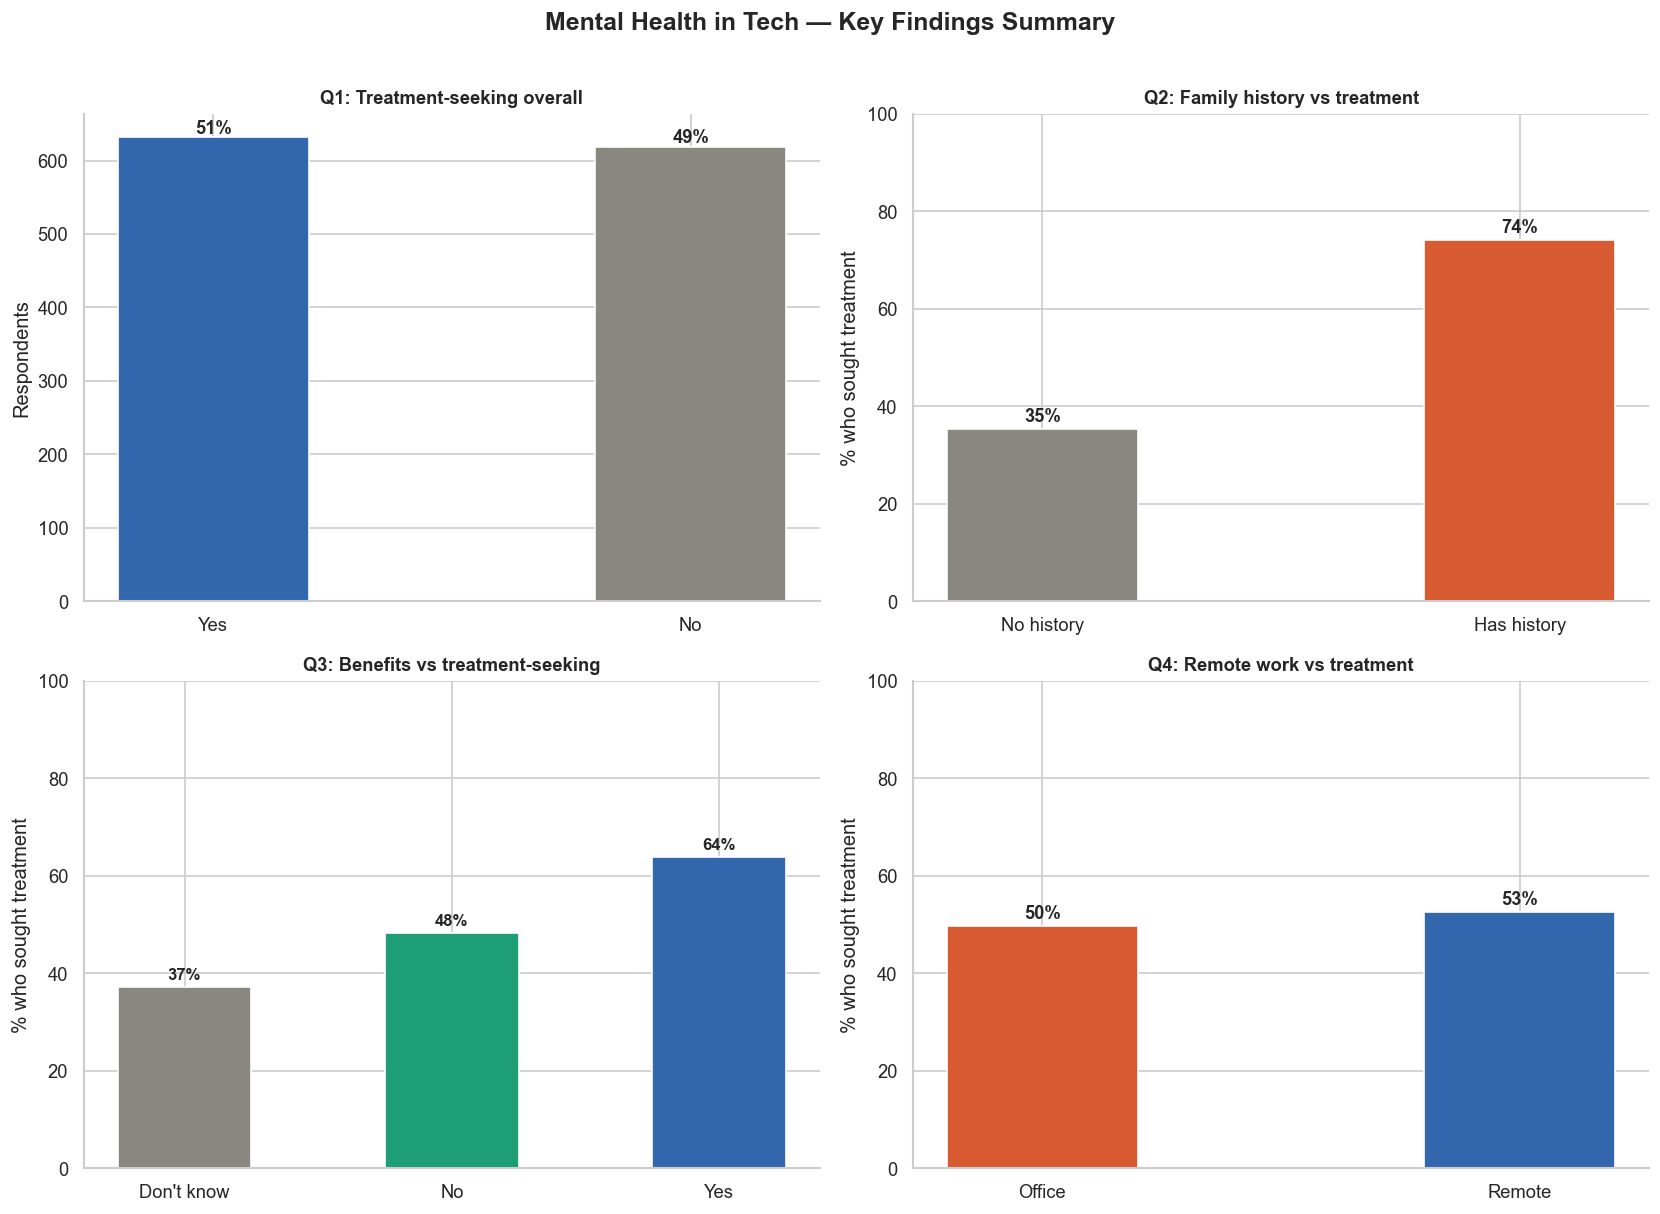

Saved: summary_dashboard.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Q1 — treatment donut (simplified as bar)
ax = axes[0, 0]
tc = df['treatment'].value_counts()
ax.bar(tc.index, tc.values, color=[C_BLUE, C_GRAY], edgecolor='white', width=0.4)
ax.set_title('Q1: Treatment-seeking overall', fontsize=11, fontweight='bold')
ax.set_ylabel('Respondents')
for p in ax.patches:
    pct = p.get_height() / total * 100
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
            f'{pct:.0f}%', ha='center', fontsize=11, fontweight='bold')

# Q2 — family history
ax = axes[0, 1]
fh = df.groupby('family_history')['treatment'].apply(lambda x: (x=='Yes').mean()*100)
bars = ax.bar(['No history', 'Has history'], fh.values,
              color=[C_GRAY, C_CORAL], edgecolor='white', width=0.4)
ax.set_title('Q2: Family history vs treatment', fontsize=11, fontweight='bold')
ax.set_ylabel('% who sought treatment')
ax.set_ylim(0, 100)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{bar.get_height():.0f}%', ha='center', fontsize=11, fontweight='bold')

# Q3 — benefits
ax = axes[1, 0]
if 'benefits' in df.columns:
    ben = df.groupby('benefits')['treatment'].apply(lambda x: (x=='Yes').mean()*100)
    ax.bar(ben.index.astype(str), ben.values,
           color=[C_GRAY, C_GREEN, C_BLUE], edgecolor='white', width=0.5)
    ax.set_title('Q3: Benefits vs treatment-seeking', fontsize=11, fontweight='bold')
    ax.set_ylabel('% who sought treatment')
    ax.set_ylim(0, 100)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 1.5,
                f'{p.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')

# Q4 — remote work
ax = axes[1, 1]
rt = df.groupby('remote_work')['treatment'].apply(lambda x: (x=='Yes').mean()*100)
ax.bar(['Office', 'Remote'], rt.values,
       color=[C_CORAL, C_BLUE], edgecolor='white', width=0.4)
ax.set_title('Q4: Remote work vs treatment', fontsize=11, fontweight='bold')
ax.set_ylabel('% who sought treatment')
ax.set_ylim(0, 100)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 1.5,
            f'{p.get_height():.0f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Mental Health in Tech — Key Findings Summary', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('summary_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: summary_dashboard.png')

---
## Summary of findings

| Question | Finding |
|---|---|
| Q1: Treatment rate | ~50% of tech employees sought mental health treatment |
| Q2: Family history | Having family history significantly increases treatment-seeking |
| Q3: Benefits | Companies with benefits and care options have higher treatment rates |
| Q4: Remote work | Slight differences between remote and office workers — see charts |

**Next step:** `03_model.ipynb` — build ML model to predict who is likely to seek treatment.